In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('merged_df15.csv')
df.head()

,Start date,End date,Total (grid load) [MWh] Original resolutions,Residual load [MWh] Original resolutions,Hydro pumped storage [MWh] Original resolutions_x,hour,day,weekday,week,month,...,Scheduled_commercial_exchanges_Austria (export) [MWh],Scheduled_commercial_exchanges_Austria (import) [MWh],Scheduled_commercial_exchanges_France (export) [MWh],Scheduled_commercial_exchanges_France (import) [MWh],Scheduled_commercial_exchanges_Poland (export) [MWh],Scheduled_commercial_exchanges_Poland (import) [MWh],Scheduled_commercial_exchanges_Norway (export) [MWh],Scheduled_commercial_exchanges_Norway (import) [MWh],Scheduled_commercial_exchanges_Belgium (export) [MWh],Scheduled_commercial_exchanges_Belgium (import) [MWh]
0,2023-01-01 00:00:00,2023-01-01 00:15:00,9673.00,1842.5,494.00,0,1,6,52,1,...,547.03,0.0,859.99,0.0,6.43,-1.43,322.25,0.0,112.90,0.00
1,2023-01-01 00:15:00,2023-01-01 00:30:00,9593.50,1691.5,502.50,0,1,6,52,1,...,547.03,0.0,859.99,0.0,6.43,-1.43,322.25,0.0,87.60,0.00
2,2023-01-01 00:30:00,2023-01-01 00:45:00,9562.00,1442.5,561.00,0,1,6,52,1,...,547.03,0.0,859.99,0.0,6.43,-1.43,322.25,0.0,83.15,0.00
3,2023-01-01 00:45:00,2023-01-01 01:00:00,9517.50,1598.5,519.25,0,1,6,52,1,...,547.03,0.0,859.99,0.0,6.43,-1.43,322.25,0.0,80.45,0.00
4,2023-01-01 01:00:00,2023-01-01 01:15:00,9433.25,1325.5,301.00,1,1,6,52,1,...,723.36,0.0,1368.55,0.0,189.40,-5.88,322.25,0.0,131.65,-501.63


In [3]:
df.shape

(207280, 128)

In [5]:
df.columns.tolist()


['Start date',
 'End date',
 'Total (grid load) [MWh] Original resolutions',
 'Residual load [MWh] Original resolutions',
 'Hydro pumped storage [MWh] Original resolutions_x',
 'hour',
 'day',
 'weekday',
 'week',
 'month',
 'year',
 'Biomass [MWh] Original resolutions',
 'Hydropower [MWh] Original resolutions',
 'Wind offshore [MWh] Original resolutions',
 'Wind onshore [MWh] Original resolutions',
 'Photovoltaics [MWh] Original resolutions',
 'Other renewable [MWh] Original resolutions',
 'Nuclear [MWh] Original resolutions',
 'Lignite [MWh] Original resolutions',
 'Hard coal [MWh] Original resolutions',
 'Fossil gas [MWh] Original resolutions',
 'Hydro pumped storage [MWh] Original resolutions_y',
 'Other conventional [MWh] Original resolutions',
 'Total Generation [MWh]',
 'Volume activated (+) [MWh] Original resolutions',
 'Volume activated (-) [MWh] Original resolutions',
 'Volume procured (+) [MW] Original resolutions',
 'Volume procured (-) [MW] Original resolutions',
 'Procure

In [4]:
rename = {
    'Total (grid load) [MWh] Original resolutions': 'Actual_consumption_Total (grid load) [MWh]',
    'Residual load [MWh] Original resolutions':'Actual_consumption_Residual load [MWh]',
    'Hydro pumped storage [MWh] Original resolutions_x': 'Actual_consumption_Hydro pumped storage [MWh]',
    'Biomass [MWh] Original resolutions': 'Actual_generation_Biomass [MWh]',
    'Hydropower [MWh] Original resolutions': 'Actual_generation_Hydropower [MWh]',
    'Wind offshore [MWh] Original resolutions': 'Actual_generation_Wind offshore [MWh]',
    'Wind onshore [MWh] Original resolutions': 'Actual_generation_Wind onshore [MWh]',
    'Photovoltaics [MWh] Original resolutions': 'Actual_generation_Photovoltaics [MWh]',
    'Other renewable [MWh] Original resolutions': 'Actual_generation_Other renewable [MWh]',
    'Nuclear [MWh] Original resolutions': 'Actual_generation_Nuclear [MWh]',
    'Lignite [MWh] Original resolutions': 'Actual_generation_Lignite [MWh]',
    'Hard coal [MWh] Original resolutions': 'Actual_generation_Hard coal [MWh]',
    'Fossil gas [MWh] Original resolutions': 'Actual_generation_Fossil gas [MWh]',
    'Hydro pumped storage [MWh] Original resolutions': 'Actual_generation_Hydro pumped storage [MWh]',
    'Other conventional [MWh] Original resolutions': 'Actual_generation_Other conventional [MWh]',
    'Total Generation [MWh]': 'Actual_generation_Total [MWh]'  
}

df.rename(columns=rename, inplace=True)


In [5]:
prefix = "Automatic_Frequency_Restoration_Reserve_"

rename = [
    'Volume activated (+) [MWh] Original resolutions',
    'Volume activated (-) [MWh] Original resolutions',
    'Volume procured (+) [MW] Original resolutions',
    'Volume procured (-) [MW] Original resolutions',
    'Procurement price (+) [€/MW] Original resolutions',
    'Procurement price (-) [€/MW] Original resolutions'
]

df.rename(columns={col: prefix + col for col in rename if col in df.columns}, inplace=True)

In [6]:
prefix = "Balancing_energy_"

rename = [
'Price [€/MWh] Original resolutions',
'Net income [€] Original resolutions'
]

df.rename(columns={col: prefix + col for col in rename if col in df.columns}, inplace=True)

In [7]:
prefix = "Costs_of_TSOs_"

rename = [
'Balancing services [€] Original resolutions',
'Network security of the TSOs [€] Original resolutions',
'Countertrading [€] Original resolutions'
]

df.rename(columns={col: prefix + col for col in rename if col in df.columns}, inplace=True)

In [8]:
prefix = "Cross-border_physical_flows_"

rename = [
 'Net export [MWh] Original resolutions',
 'Netherlands (export) [MWh] Original resolutions',
 'Netherlands (import) [MWh] Original resolutions',
 'Switzerland (export) [MWh] Original resolutions',
 'Switzerland (import) [MWh] Original resolutions',
 'Denmark (export) [MWh] Original resolutions',
 'Denmark (import) [MWh] Original resolutions',
 'Czech Republic (export) [MWh] Original resolutions',
 'Czech Republic (import) [MWh] Original resolutions',
 'Luxembourg (export) [MWh] Original resolutions',
 'Luxembourg (import) [MWh] Original resolutions',
 'Sweden (export) [MWh] Original resolutions',
 'Sweden (import) [MWh] Original resolutions',
 'Austria (export) [MWh] Original resolutions',
 'Austria (import) [MWh] Original resolutions',
 'France (export) [MWh] Original resolutions',
 'France (import) [MWh] Original resolutions',
 'Poland (export) [MWh] Original resolutions',
 'Poland (import) [MWh] Original resolutions',
 'Norway (export) [MWh] Original resolutions',
 'Norway (import) [MWh] Original resolutions',
 'Belgium (export) [MWh] Original resolutions',
 'Belgium (import) [MWh] Original resolutions'
]

df.rename(columns={col: prefix + col for col in rename if col in df.columns}, inplace=True)

In [9]:
prefix = "Day-ahead_prices_"

rename = [
 'Germany/Luxembourg [€/MWh] Original resolutions',
 '∅ DE/LU neighbours [€/MWh] Original resolutions',
 'Belgium [€/MWh] Original resolutions',
 'Denmark 1 [€/MWh] Original resolutions',
 'Denmark 2 [€/MWh] Original resolutions',
 'France [€/MWh] Original resolutions',
 'Netherlands [€/MWh] Original resolutions',
 'Norway 2 [€/MWh] Original resolutions',
 'Austria [€/MWh] Original resolutions',
 'Poland [€/MWh] Original resolutions',
 'Sweden 4 [€/MWh] Original resolutions',
 'Switzerland [€/MWh] Original resolutions',
 'Czech Republic [€/MWh] Original resolutions',
 'Northern Italy [€/MWh] Original resolutions',
 'Slovenia [€/MWh] Original resolutions',
 'Hungary [€/MWh] Original resolutions'
]

df.rename(columns={col: prefix + col for col in rename if col in df.columns}, inplace=True)

In [10]:
prefix = "Exported_balancing_services_"

rename = [
'Austria [MWh] Original resolutions'
]

df.rename(columns={col: prefix + col for col in rename if col in df.columns}, inplace=True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207280 entries, 0 to 207279
Columns: 128 entries, Start date to Scheduled_commercial_exchanges_Belgium (import) [MWh]
dtypes: float64(120), int64(6), object(2)
memory usage: 202.4+ MB


In [12]:
# df.to_csv('final.csv', index=False)

# Exploratory Data Analysis (EDA)


### **1. Market Trends & Price Fluctuations**

- #### *How do electricity prices fluctuate hourly, daily, and weekly across differt countries?*

In [13]:
df.head()

,Start date,End date,Actual_consumption_Total (grid load) [MWh],Actual_consumption_Residual load [MWh],Actual_consumption_Hydro pumped storage [MWh],hour,day,weekday,week,month,...,Scheduled_commercial_exchanges_Austria (export) [MWh],Scheduled_commercial_exchanges_Austria (import) [MWh],Scheduled_commercial_exchanges_France (export) [MWh],Scheduled_commercial_exchanges_France (import) [MWh],Scheduled_commercial_exchanges_Poland (export) [MWh],Scheduled_commercial_exchanges_Poland (import) [MWh],Scheduled_commercial_exchanges_Norway (export) [MWh],Scheduled_commercial_exchanges_Norway (import) [MWh],Scheduled_commercial_exchanges_Belgium (export) [MWh],Scheduled_commercial_exchanges_Belgium (import) [MWh]
0,2023-01-01 00:00:00,2023-01-01 00:15:00,9673.00,1842.5,494.00,0,1,6,52,1,...,547.03,0.0,859.99,0.0,6.43,-1.43,322.25,0.0,112.90,0.00
1,2023-01-01 00:15:00,2023-01-01 00:30:00,9593.50,1691.5,502.50,0,1,6,52,1,...,547.03,0.0,859.99,0.0,6.43,-1.43,322.25,0.0,87.60,0.00
2,2023-01-01 00:30:00,2023-01-01 00:45:00,9562.00,1442.5,561.00,0,1,6,52,1,...,547.03,0.0,859.99,0.0,6.43,-1.43,322.25,0.0,83.15,0.00
3,2023-01-01 00:45:00,2023-01-01 01:00:00,9517.50,1598.5,519.25,0,1,6,52,1,...,547.03,0.0,859.99,0.0,6.43,-1.43,322.25,0.0,80.45,0.00
4,2023-01-01 01:00:00,2023-01-01 01:15:00,9433.25,1325.5,301.00,1,1,6,52,1,...,723.36,0.0,1368.55,0.0,189.40,-5.88,322.25,0.0,131.65,-501.63


In [14]:
columns = [
    'Balancing_energy_Price [€/MWh] Original resolutions',
    'Day-ahead_prices_Germany/Luxembourg [€/MWh] Original resolutions',
    'Day-ahead_prices_Belgium [€/MWh] Original resolutions',
    'Day-ahead_prices_Denmark 1 [€/MWh] Original resolutions',
    'Day-ahead_prices_Denmark 2 [€/MWh] Original resolutions',
    'Day-ahead_prices_France [€/MWh] Original resolutions',
    'Day-ahead_prices_Netherlands [€/MWh] Original resolutions',
    'Day-ahead_prices_Norway 2 [€/MWh] Original resolutions',
    'Day-ahead_prices_Austria [€/MWh] Original resolutions',
    'Day-ahead_prices_Poland [€/MWh] Original resolutions',
    'Day-ahead_prices_Sweden 4 [€/MWh] Original resolutions',
    'Day-ahead_prices_Switzerland [€/MWh] Original resolutions',
    'Day-ahead_prices_Czech Republic [€/MWh] Original resolutions',
    'Day-ahead_prices_Northern Italy [€/MWh] Original resolutions',
    'Day-ahead_prices_Slovenia [€/MWh] Original resolutions',
    'Day-ahead_prices_Hungary [€/MWh] Original resolutions'
]

hourly_prices = df.groupby('hour')[columns].mean()

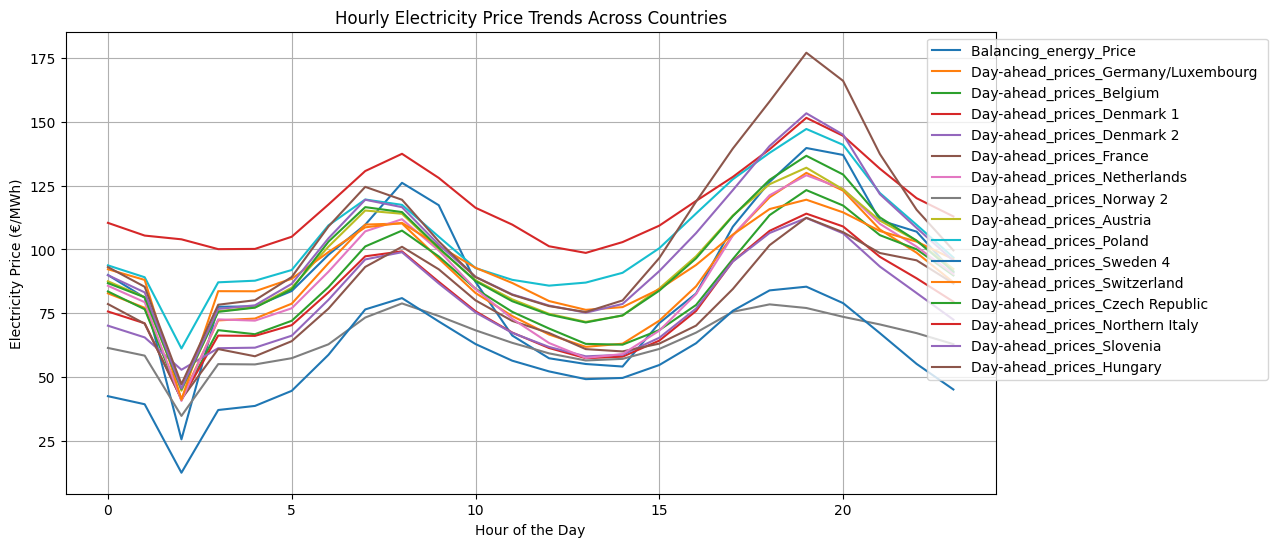

In [15]:
plt.figure(figsize=(12,6))

for col in columns:
    plt.plot(hourly_prices.index, hourly_prices[col], label = col.replace('[€/MWh] Original resolutions',''))
plt.xlabel("Hour of the Day")
plt.ylabel("Electricity Price (€/MWh)")
plt.title("Hourly Electricity Price Trends Across Countries")
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.grid()
plt.show()

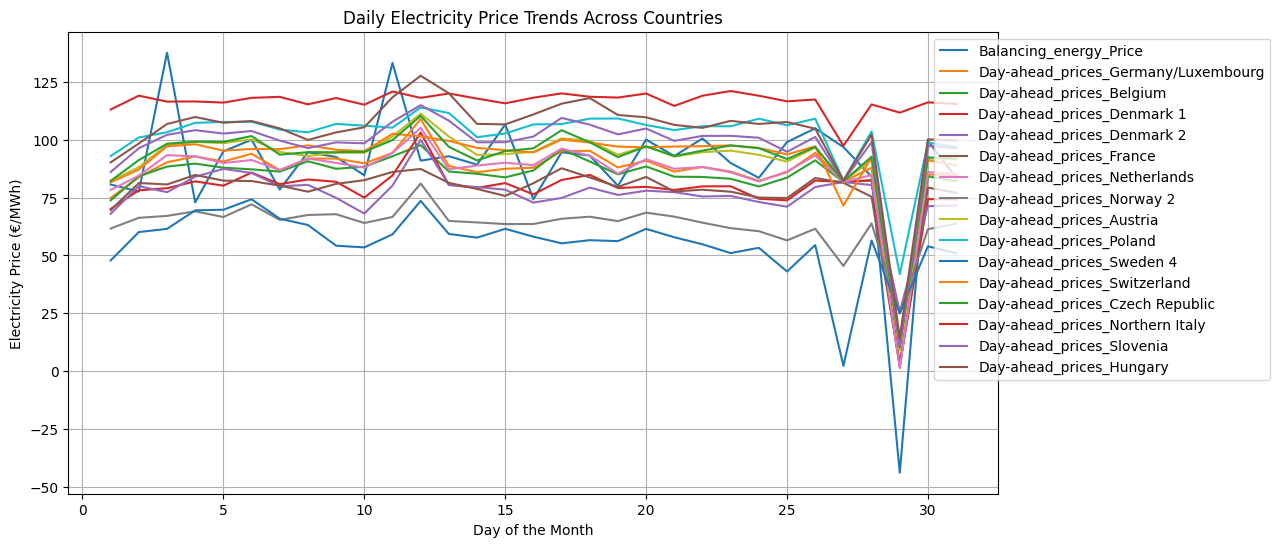

In [16]:
daily_prices = df.groupby('day')[columns].mean()

plt.figure(figsize=(12, 6))
for col in columns:
    plt.plot(daily_prices.index, daily_prices[col], label=col.replace(' [€/MWh] Original resolutions', ''))

plt.xlabel("Day of the Month")
plt.ylabel("Electricity Price (€/MWh)")
plt.title("Daily Electricity Price Trends Across Countries")
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.grid()
plt.show()


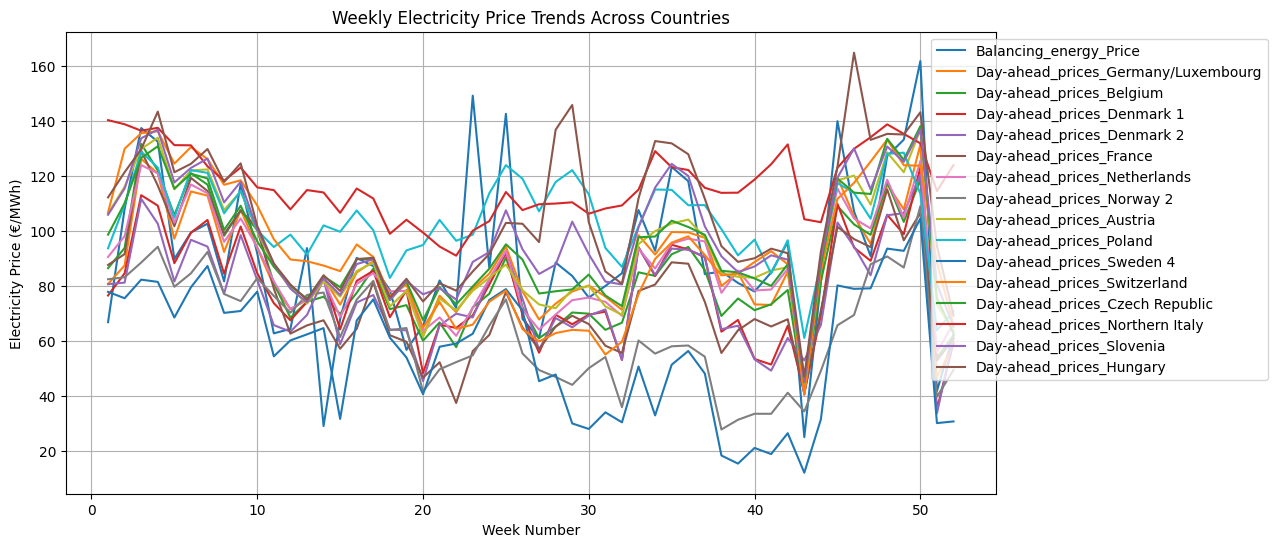

In [17]:
weekly_prices = df.groupby('week')[columns].mean()

plt.figure(figsize=(12, 6))
for col in columns:
    plt.plot(weekly_prices.index, weekly_prices[col], label=col.replace(' [€/MWh] Original resolutions', ''))

plt.xlabel("Week Number")
plt.ylabel("Electricity Price (€/MWh)")
plt.title("Weekly Electricity Price Trends Across Countries")
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.grid()
plt.show()

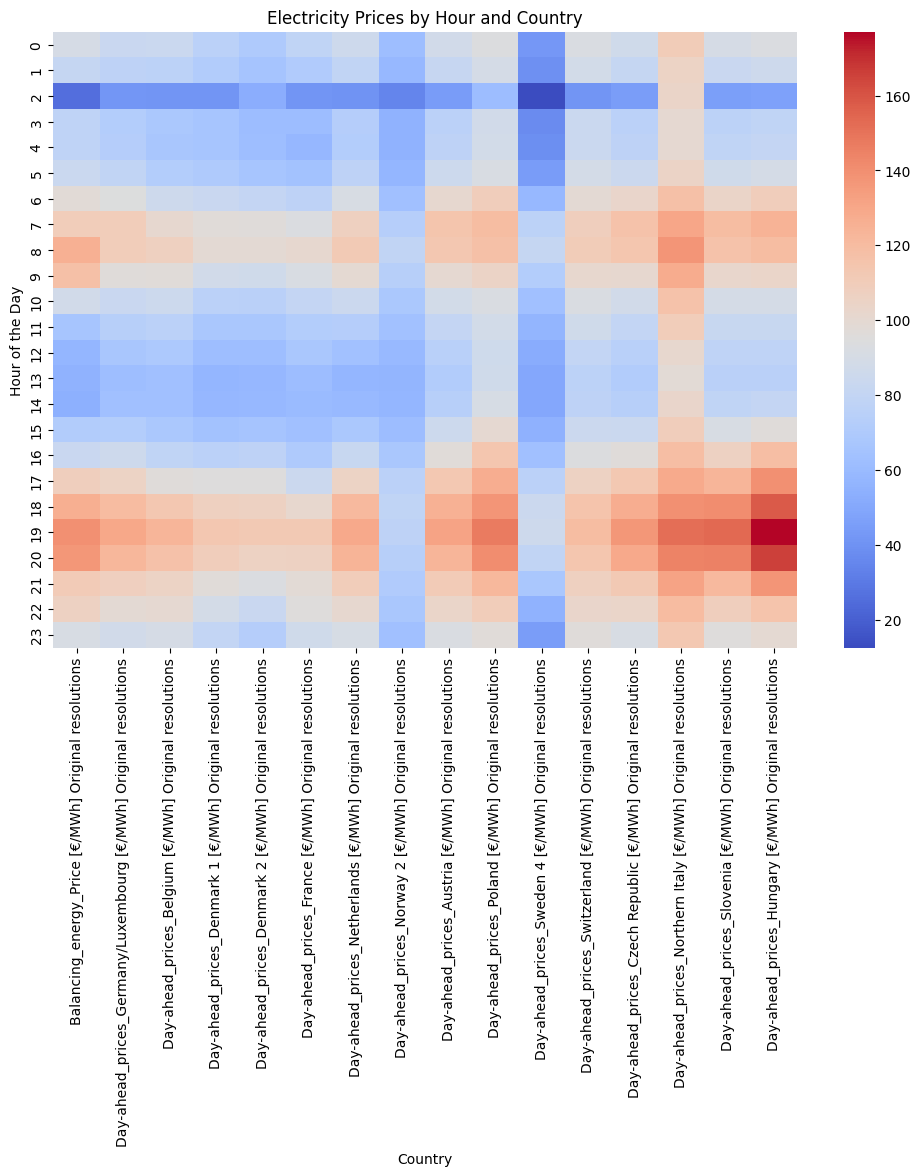

In [18]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.groupby('hour')[columns].mean(), cmap="coolwarm", annot=False)
plt.xlabel("Country")
plt.ylabel("Hour of the Day")
plt.title("Electricity Prices by Hour and Country")
plt.show()

- #### *How do electricity consumption patterns change in the same timeframes, and how does this impact pricing?*

In [19]:
hourly_consumption = df.groupby('hour')[
    ['Actual_consumption_Total (grid load) [MWh]', 'Actual_consumption_Residual load [MWh]']
].mean()
daily_consumption = df.groupby('day')[['Actual_consumption_Total (grid load) [MWh]']].mean()
weekly_consumption = df.groupby('week')[['Actual_consumption_Total (grid load) [MWh]']].mean()

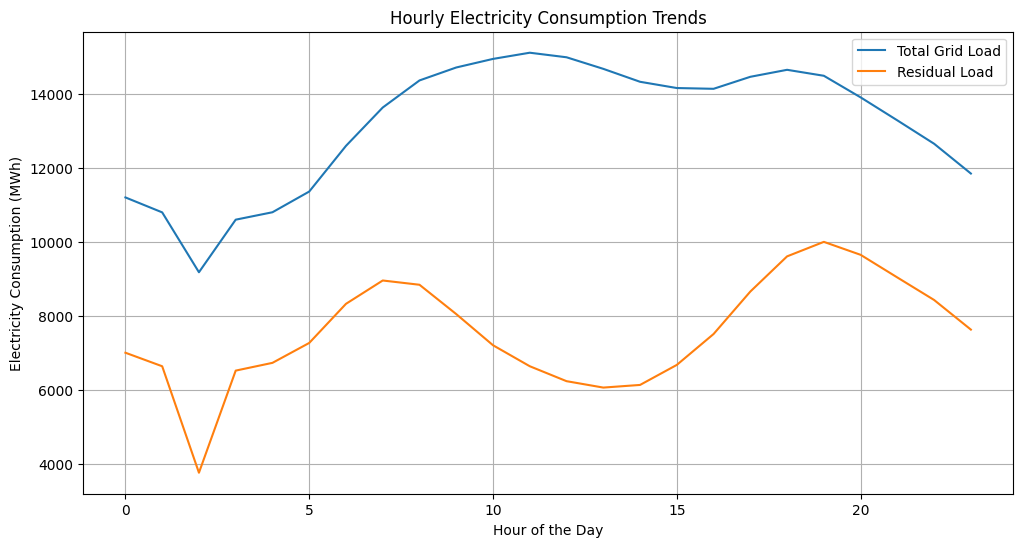

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(hourly_consumption.index, hourly_consumption['Actual_consumption_Total (grid load) [MWh]'], label="Total Grid Load")
plt.plot(hourly_consumption.index, hourly_consumption['Actual_consumption_Residual load [MWh]'], label="Residual Load")

plt.xlabel("Hour of the Day")
plt.ylabel("Electricity Consumption (MWh)")
plt.title("Hourly Electricity Consumption Trends")
plt.legend()
plt.grid()
plt.show()

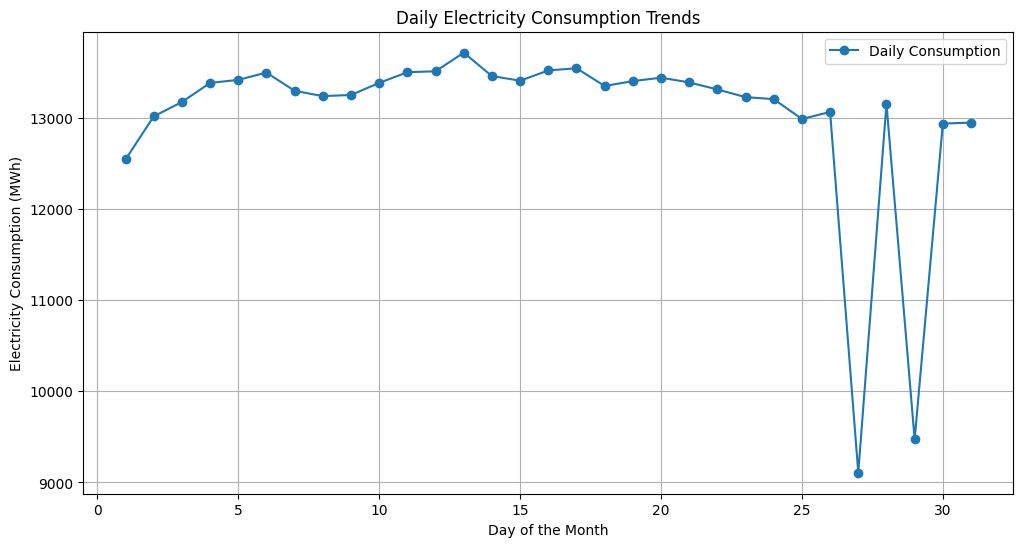

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(daily_consumption.index, daily_consumption['Actual_consumption_Total (grid load) [MWh]'], label="Daily Consumption", marker='o')
plt.xlabel("Day of the Month")
plt.ylabel("Electricity Consumption (MWh)")
plt.title("Daily Electricity Consumption Trends")
plt.legend()
plt.grid()
plt.show()

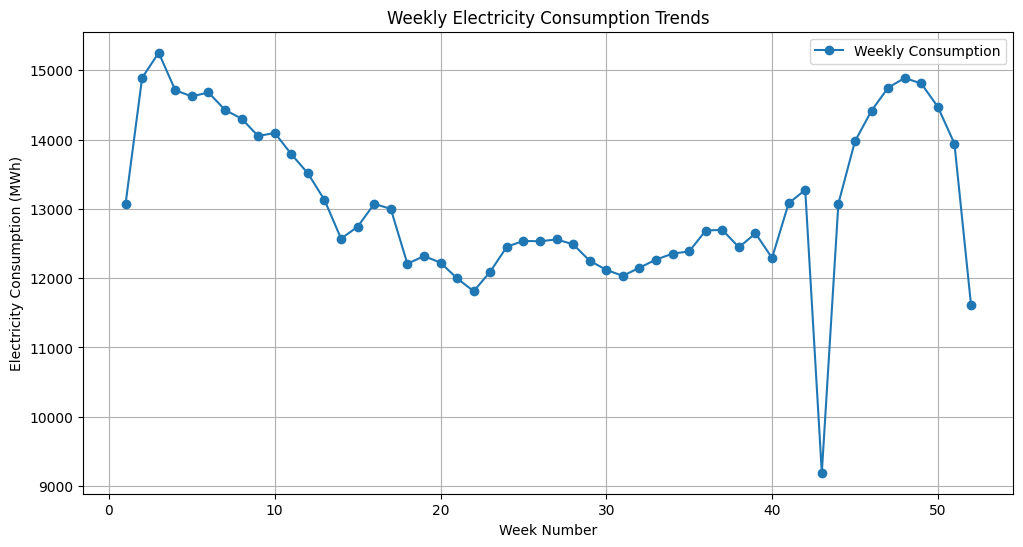

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(weekly_consumption.index, weekly_consumption['Actual_consumption_Total (grid load) [MWh]'], label="Weekly Consumption", marker='o')
plt.xlabel("Week Number")
plt.ylabel("Electricity Consumption (MWh)")
plt.title("Weekly Electricity Consumption Trends")
plt.legend()
plt.grid()
plt.show()

- #### *How does electricity generation (actual vs. forecast) align with price trends?*

In [23]:
df['Forecast_Error'] = (df['Forecasted_generation_Total [MWh]'] - df['Actual_generation_Total [MWh]']) / df['Actual_generation_Total [MWh]'] * 100

df[['Actual_generation_Total [MWh]', 'Forecasted_generation_Total [MWh]', 'Forecast_Error']].describe()


,Actual_generation_Total [MWh],Forecasted_generation_Total [MWh],Forecast_Error
count,207280.000000,51772.000000,5.177200e+04
mean,10682.018015,42337.611547,inf
std,2502.079307,9694.446721,NaN
min,0.000000,20000.000000,2.182772e+02
25%,8662.000000,34075.000000,2.827469e+02
50%,10619.500000,41164.000000,2.944296e+02
75%,11242.750000,44140.750000,3.030737e+02
max,21652.000000,86901.000000,inf


In [24]:
daily_data = df.groupby(['year', 'month', 'day']).agg({
    'Actual_generation_Total [MWh]': 'sum',
    'Forecasted_generation_Total [MWh]': 'sum',
    'Day-ahead_prices_Germany/Luxembourg [€/MWh] Original resolutions': 'mean'
}).reset_index()

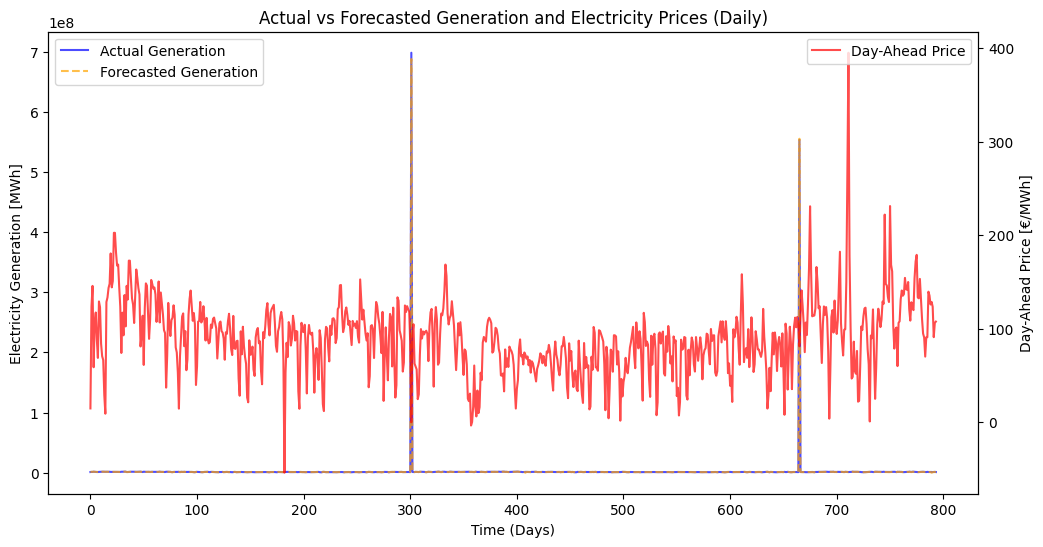

In [25]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(daily_data.index, daily_data['Actual_generation_Total [MWh]'], label='Actual Generation', color='blue', alpha=0.7)
ax1.plot(daily_data.index, daily_data['Forecasted_generation_Total [MWh]'], label='Forecasted Generation', color='orange', linestyle='dashed', alpha=0.7)
ax1.set_ylabel("Electricity Generation [MWh]")
ax1.set_xlabel("Time (Days)")
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(daily_data.index, daily_data['Day-ahead_prices_Germany/Luxembourg [€/MWh] Original resolutions'], label='Day-Ahead Price', color='red', alpha=0.7)
ax2.set_ylabel("Day-Ahead Price [€/MWh]")
ax2.legend(loc='upper right')

plt.title("Actual vs Forecasted Generation and Electricity Prices (Daily)")
plt.show()

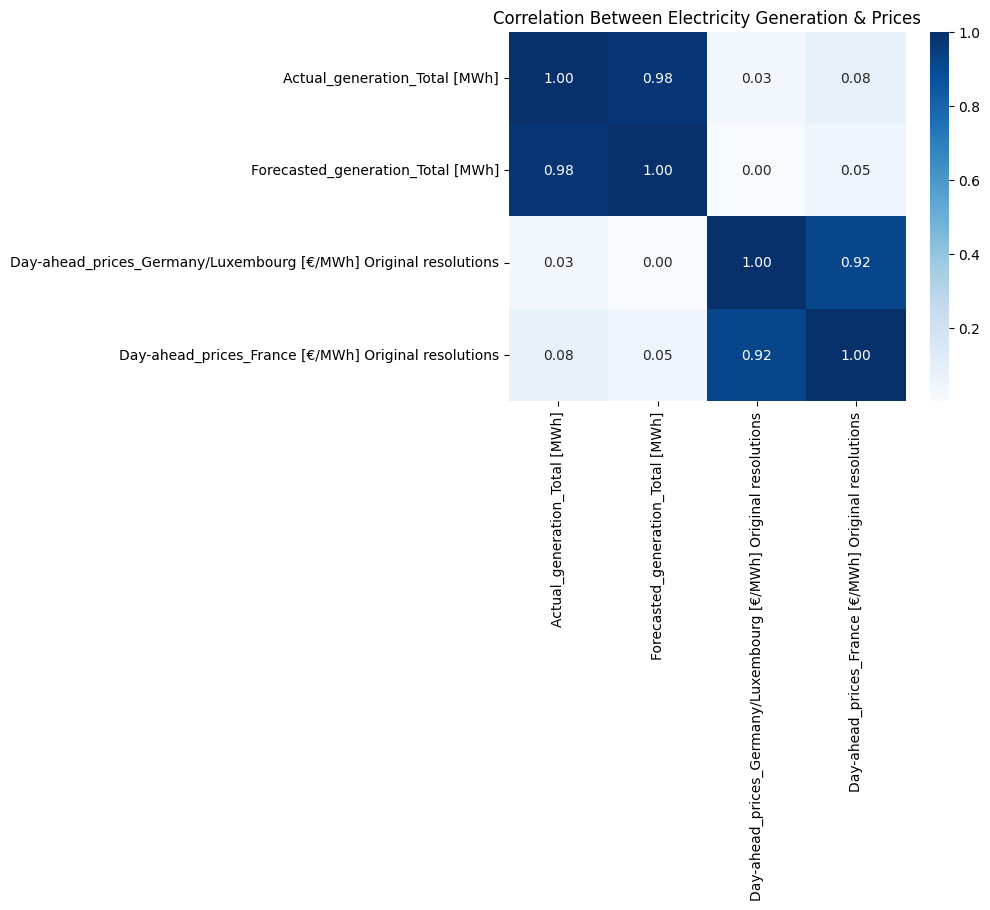

In [26]:
correlation = df[
    ['Actual_generation_Total [MWh]', 'Forecasted_generation_Total [MWh]'] + 
    ['Day-ahead_prices_Germany/Luxembourg [€/MWh] Original resolutions', 'Day-ahead_prices_France [€/MWh] Original resolutions']
]

correlation_matrix = correlation.corr()

sns.heatmap(correlation_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Between Electricity Generation & Prices")
plt.show()


- #### *What patterns emerge from scheduled commercial exchanges and cross-border physical flows?*

In [27]:
grouped = df.groupby(['year','month','day']).sum().reset_index()

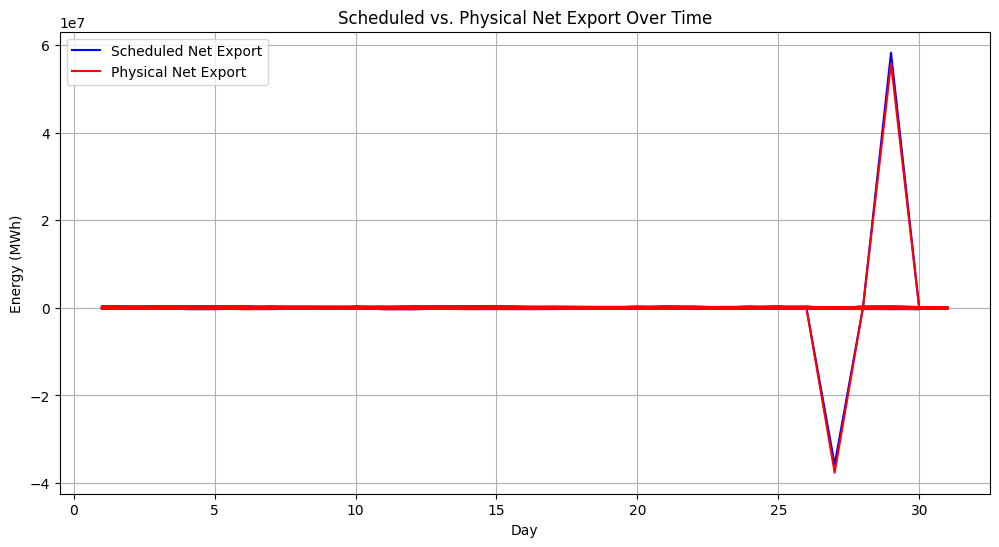

In [28]:
plt.figure(figsize=(12, 6))
plt.plot(grouped['day'], grouped['Scheduled_commercial_exchanges_Net export [MWh]'], label='Scheduled Net Export', color='blue')
plt.plot(grouped['day'], grouped['Cross-border_physical_flows_Net export [MWh] Original resolutions'], label='Physical Net Export', color='red')

plt.xlabel('Day')
plt.ylabel('Energy (MWh)')
plt.title('Scheduled vs. Physical Net Export Over Time')
plt.legend()
plt.grid()
plt.show()

In [29]:
countries = ['Netherlands', 'Switzerland', 'Denmark', 'Czech Republic', 'Luxembourg', 'Sweden', 
             'Austria', 'France', 'Poland', 'Norway', 'Belgium']

net_flows = {}

for country in countries:
    export_col = f'Cross-border_physical_flows_{country} (export) [MWh] Original resolutions'
    import_col = f'Cross-border_physical_flows_{country} (import) [MWh] Original resolutions'
    
    if export_col in df.columns and import_col in df.columns:
        net_flows[country] = (df[export_col] - df[import_col]).mean()

flow_df = pd.DataFrame(net_flows.items(), columns=['Country', 'Net Flow (MWh)'])


In [45]:
flow_df

,Country,Net Flow (MWh)
0,Netherlands,653.780875
1,Switzerland,356.928532
2,Denmark,448.343013
3,Czech Republic,363.626336
4,Luxembourg,42.670514
5,Sweden,106.041030
6,Austria,483.568031
7,France,756.393792
8,Poland,355.263234
9,Norway,240.188644


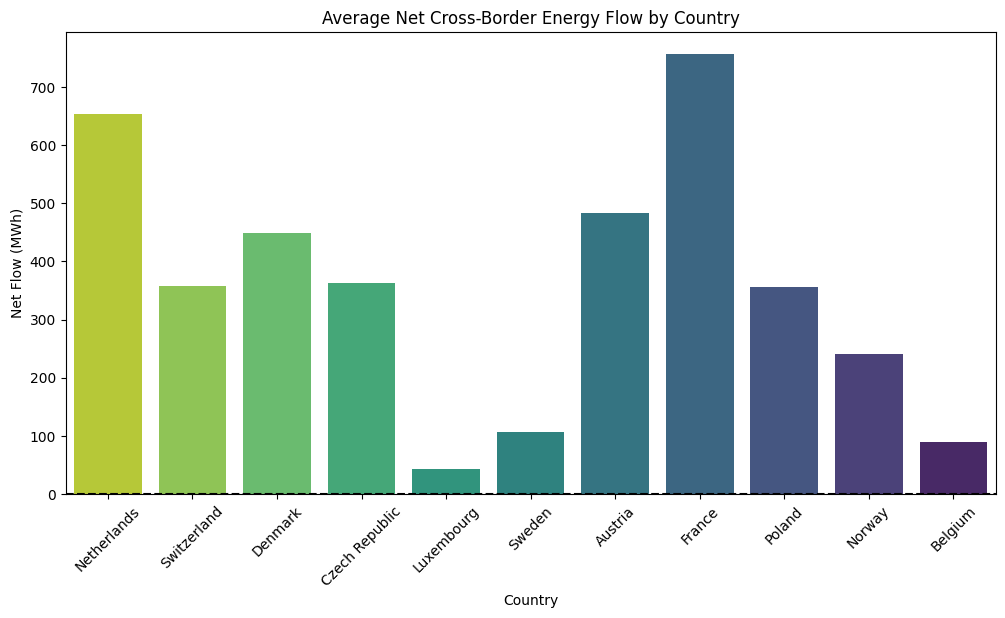

In [30]:
plt.figure(figsize=(12, 6))
sns.barplot(data=flow_df, x='Country', y='Net Flow (MWh)', palette='viridis_r')
plt.axhline(0, color='black', linestyle='dashed')
plt.title('Average Net Cross-Border Energy Flow by Country')
plt.xticks(rotation=45)
plt.show()

### **2. Correlation & Feature Relationships**

- #### *What features have the strongest correlation with electricity prices?*

In [ ]:
numeric_data = df.select_dtypes(include=['number'])

price_corr = numeric_data.corr()['Day-ahead_prices_Germany/Luxembourg [€/MWh] Original resolutions'].dropna()

top_pos_corr = price_corr.sort_values(ascending=False).iloc[1:11]
top_neg_corr = price_corr.sort_values(ascending=True).iloc[:10]

top_features = pd.concat([top_pos_corr, top_neg_corr])

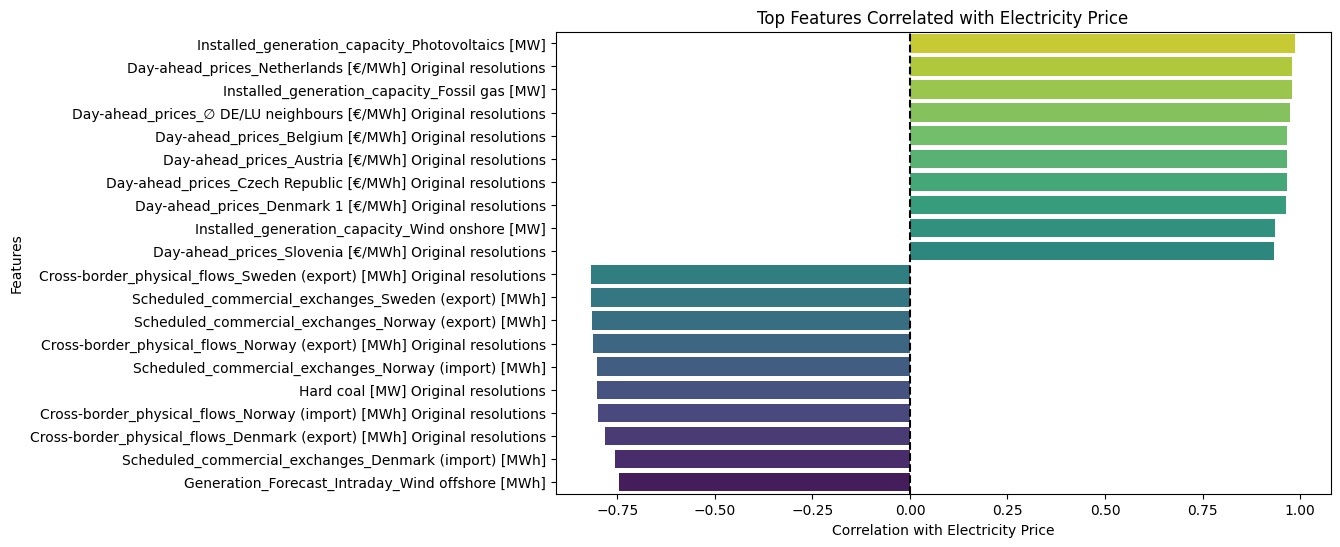

In [32]:
plt.figure(figsize=(10, 6))
sns.barplot(y=top_features.index, x=top_features.values, palette="viridis_r")
plt.axvline(0, color='black', linestyle='dashed')
plt.xlabel('Correlation with Electricity Price')
plt.ylabel('Features')
plt.title('Top Features Correlated with Electricity Price')
plt.show()

- #### *How do electricity prices correlate between different countries?*

In [33]:
price_columns = [
    'Day-ahead_prices_Germany/Luxembourg [€/MWh] Original resolutions',
    'Day-ahead_prices_∅ DE/LU neighbours [€/MWh] Original resolutions',
    'Day-ahead_prices_Belgium [€/MWh] Original resolutions',
    'Day-ahead_prices_Denmark 1 [€/MWh] Original resolutions',
    'Day-ahead_prices_Denmark 2 [€/MWh] Original resolutions',
    'Day-ahead_prices_France [€/MWh] Original resolutions',
    'Day-ahead_prices_Netherlands [€/MWh] Original resolutions',
    'Day-ahead_prices_Norway 2 [€/MWh] Original resolutions',
    'Day-ahead_prices_Austria [€/MWh] Original resolutions',
    'Day-ahead_prices_Poland [€/MWh] Original resolutions',
    'Day-ahead_prices_Sweden 4 [€/MWh] Original resolutions',
    'Day-ahead_prices_Switzerland [€/MWh] Original resolutions',
    'Day-ahead_prices_Czech Republic [€/MWh] Original resolutions',
    'Day-ahead_prices_Northern Italy [€/MWh] Original resolutions',
    'Day-ahead_prices_Slovenia [€/MWh] Original resolutions',
    'Day-ahead_prices_Hungary [€/MWh] Original resolutions'
]

price_data = df[price_columns]

In [34]:
price_corr= price_data.corr()

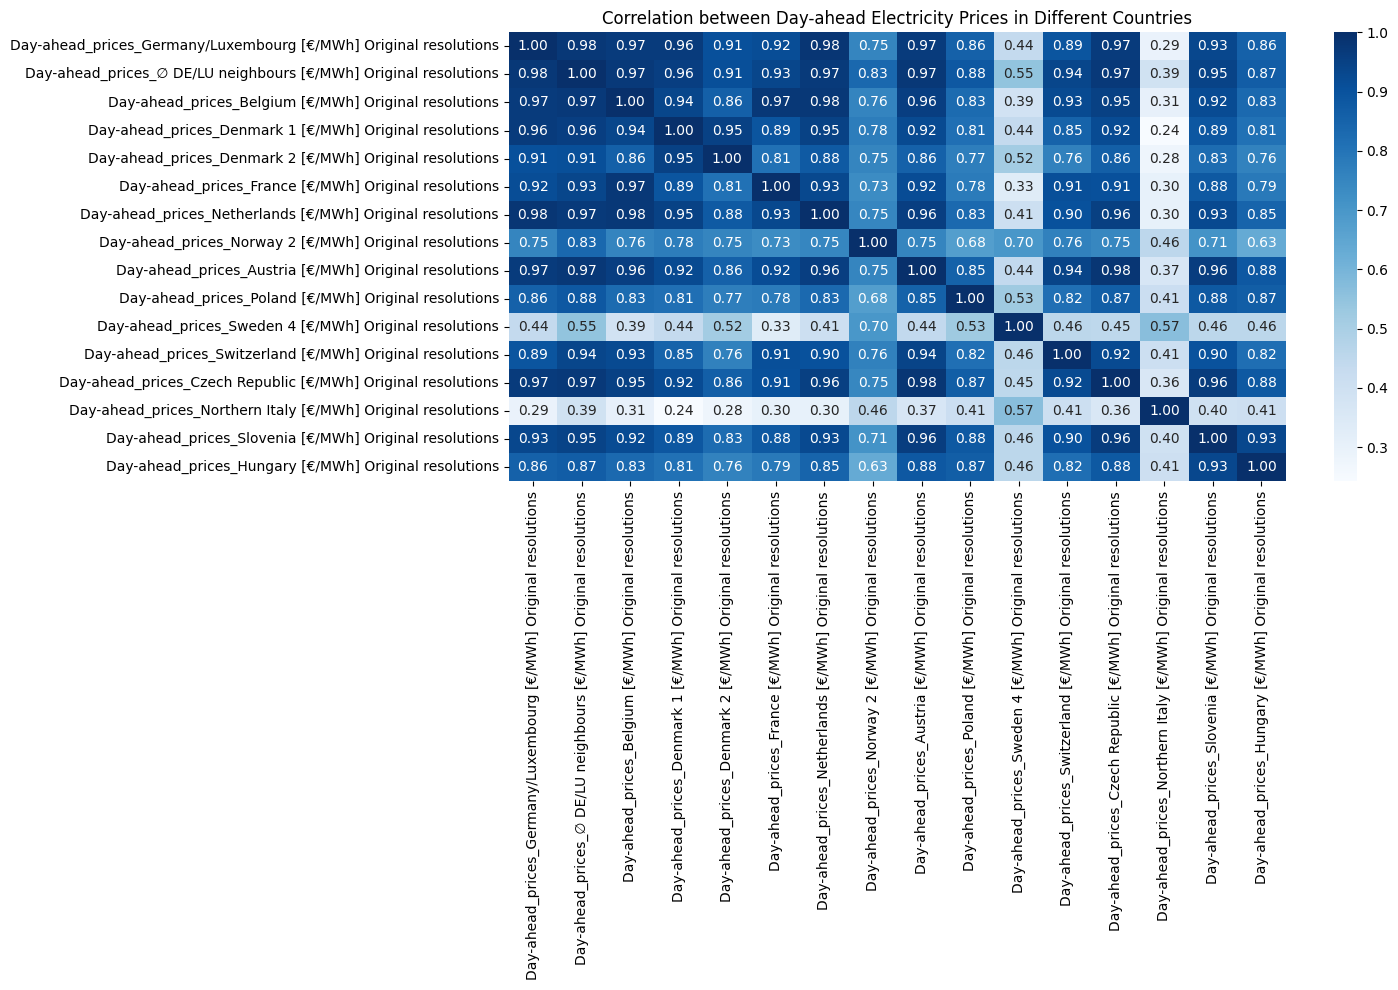

In [35]:
plt.figure(figsize=(15, 10))
sns.heatmap(price_corr, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation between Day-ahead Electricity Prices in Different Countries')
plt.tight_layout()
plt.show()

In [36]:
price_corr

,Day-ahead_prices_Germany/Luxembourg [€/MWh] Original resolutions,Day-ahead_prices_∅ DE/LU neighbours [€/MWh] Original resolutions,Day-ahead_prices_Belgium [€/MWh] Original resolutions,Day-ahead_prices_Denmark 1 [€/MWh] Original resolutions,Day-ahead_prices_Denmark 2 [€/MWh] Original resolutions,Day-ahead_prices_France [€/MWh] Original resolutions,Day-ahead_prices_Netherlands [€/MWh] Original resolutions,Day-ahead_prices_Norway 2 [€/MWh] Original resolutions,Day-ahead_prices_Austria [€/MWh] Original resolutions,Day-ahead_prices_Poland [€/MWh] Original resolutions,Day-ahead_prices_Sweden 4 [€/MWh] Original resolutions,Day-ahead_prices_Switzerland [€/MWh] Original resolutions,Day-ahead_prices_Czech Republic [€/MWh] Original resolutions,Day-ahead_prices_Northern Italy [€/MWh] Original resolutions,Day-ahead_prices_Slovenia [€/MWh] Original resolutions,Day-ahead_prices_Hungary [€/MWh] Original resolutions
Day-ahead_prices_Germany/Luxembourg [€/MWh] Original resolutions,1.000000,0.975180,0.966526,0.964499,0.905943,0.915715,0.980121,0.753831,0.965548,0.857068,0.437018,0.892704,0.965426,0.293878,0.934436,0.856572
Day-ahead_prices_∅ DE/LU neighbours [€/MWh] Original resolutions,0.975180,1.000000,0.970974,0.957528,0.910643,0.934885,0.969740,0.834368,0.973922,0.883865,0.548434,0.937787,0.971328,0.392278,0.945110,0.869610
Day-ahead_prices_Belgium [€/MWh] Original resolutions,0.966526,0.970974,1.000000,0.935489,0.858832,0.974248,0.975951,0.755906,0.957363,0.826074,0.388883,0.925289,0.950649,0.306605,0.921751,0.833539
Day-ahead_prices_Denmark 1 [€/MWh] Original resolutions,0.964499,0.957528,0.935489,1.000000,0.950927,0.891901,0.948698,0.778006,0.923194,0.813735,0.435669,0.849212,0.922377,0.242286,0.887513,0.809803
Day-ahead_prices_Denmark 2 [€/MWh] Original resolutions,0.905943,0.910643,0.858832,0.950927,1.000000,0.808336,0.876445,0.751958,0.857608,0.774530,0.516335,0.763309,0.863758,0.277644,0.825125,0.761889
Day-ahead_prices_France [€/MWh] Original resolutions,0.915715,0.934885,0.974248,0.891901,0.808336,1.000000,0.929207,0.731219,0.920076,0.781479,0.333672,0.909561,0.905716,0.303001,0.879233,0.788734
Day-ahead_prices_Netherlands [€/MWh] Original resolutions,0.980121,0.969740,0.975951,0.948698,0.876445,0.929207,1.000000,0.749877,0.958262,0.832828,0.408935,0.903611,0.955145,0.302354,0.927092,0.847884
Day-ahead_prices_Norway 2 [€/MWh] Original resolutions,0.753831,0.834368,0.755906,0.778006,0.751958,0.731219,0.749877,1.000000,0.754105,0.676219,0.699444,0.764051,0.746838,0.455140,0.711985,0.634564
Day-ahead_prices_Austria [€/MWh] Original resolutions,0.965548,0.973922,0.957363,0.923194,0.857608,0.920076,0.958262,0.754105,1.000000,0.853259,0.443225,0.942067,0.981811,0.366134,0.959783,0.881863
Day-ahead_prices_Poland [€/MWh] Original resolutions,0.857068,0.883865,0.826074,0.813735,0.774530,0.781479,0.832828,0.676219,0.853259,1.000000,0.525445,0.815484,0.866756,0.411519,0.879383,0.865497


- #### *What is the relationship between forecasted vs. actual electricity generation and consumption?*

In [37]:
df['Gen_diff'] = df['Actual_generation_Total [MWh]'] - df['Forecasted_generation_Total [MWh]']
df['Cons_diff'] = df['Actual_consumption_Total (grid load) [MWh]'] - df['Forecasted_consumption_Total (grid load) [MWh]']


In [38]:
gen_corr =  df[['Forecasted_generation_Total [MWh]', 'Actual_generation_Total [MWh]']].corr().iloc[0,1]
print(f"Correlation between forecasted and actual generation: {gen_corr:.4f}")

Correlation between forecasted and actual generation: 0.9798


In [39]:
cons_corr  =  df[['Forecasted_consumption_Total (grid load) [MWh]', 'Actual_consumption_Total (grid load) [MWh]']].corr().iloc[0,1]
print(f"Correlation between forecasted and actual generation: {cons_corr:.4f}")

Correlation between forecasted and actual generation: 0.9837


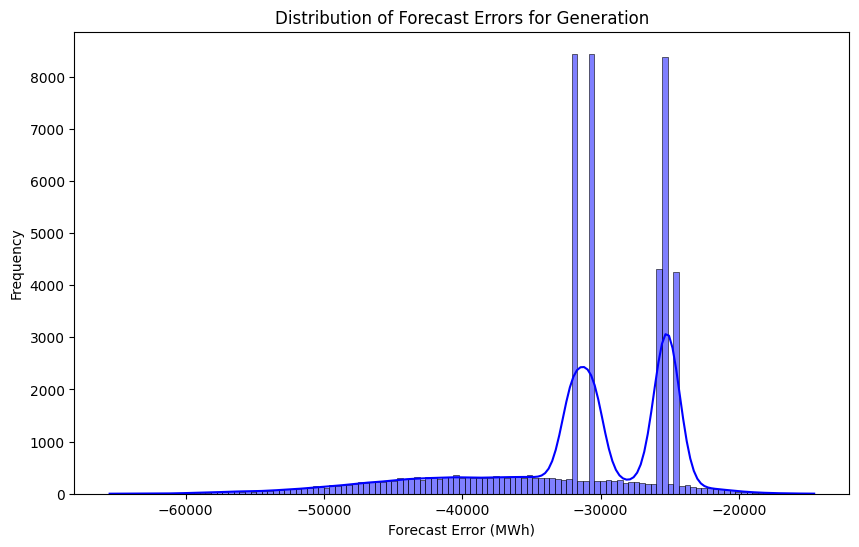

In [40]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Gen_diff'], kde=True, color='blue')
plt.title('Distribution of Forecast Errors for Generation')
plt.xlabel('Forecast Error (MWh)')
plt.ylabel('Frequency')
plt.show()

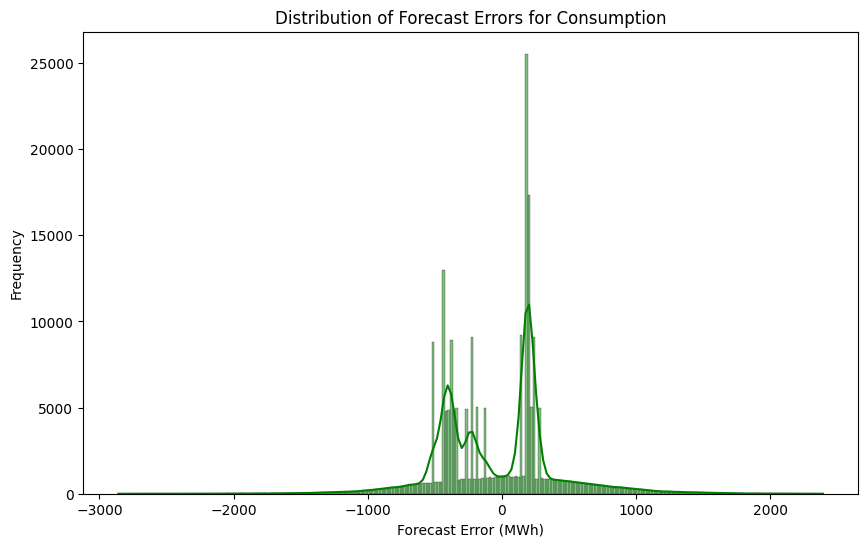

In [41]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Cons_diff'], kde=True, color='green')
plt.title('Distribution of Forecast Errors for Consumption')
plt.xlabel('Forecast Error (MWh)')
plt.ylabel('Frequency')
plt.show()

- #### *How do balancing reserves and TSO costs impact electricity prices?*

In [42]:
correlation_data = df[['Day-ahead_prices_Germany/Luxembourg [€/MWh] Original resolutions',
                          'Automatic_Frequency_Restoration_Reserve_Volume activated (+) [MWh] Original resolutions',
                          'Costs_of_TSOs_Balancing services [€] Original resolutions']]

correlation_matrix = correlation_data.corr()

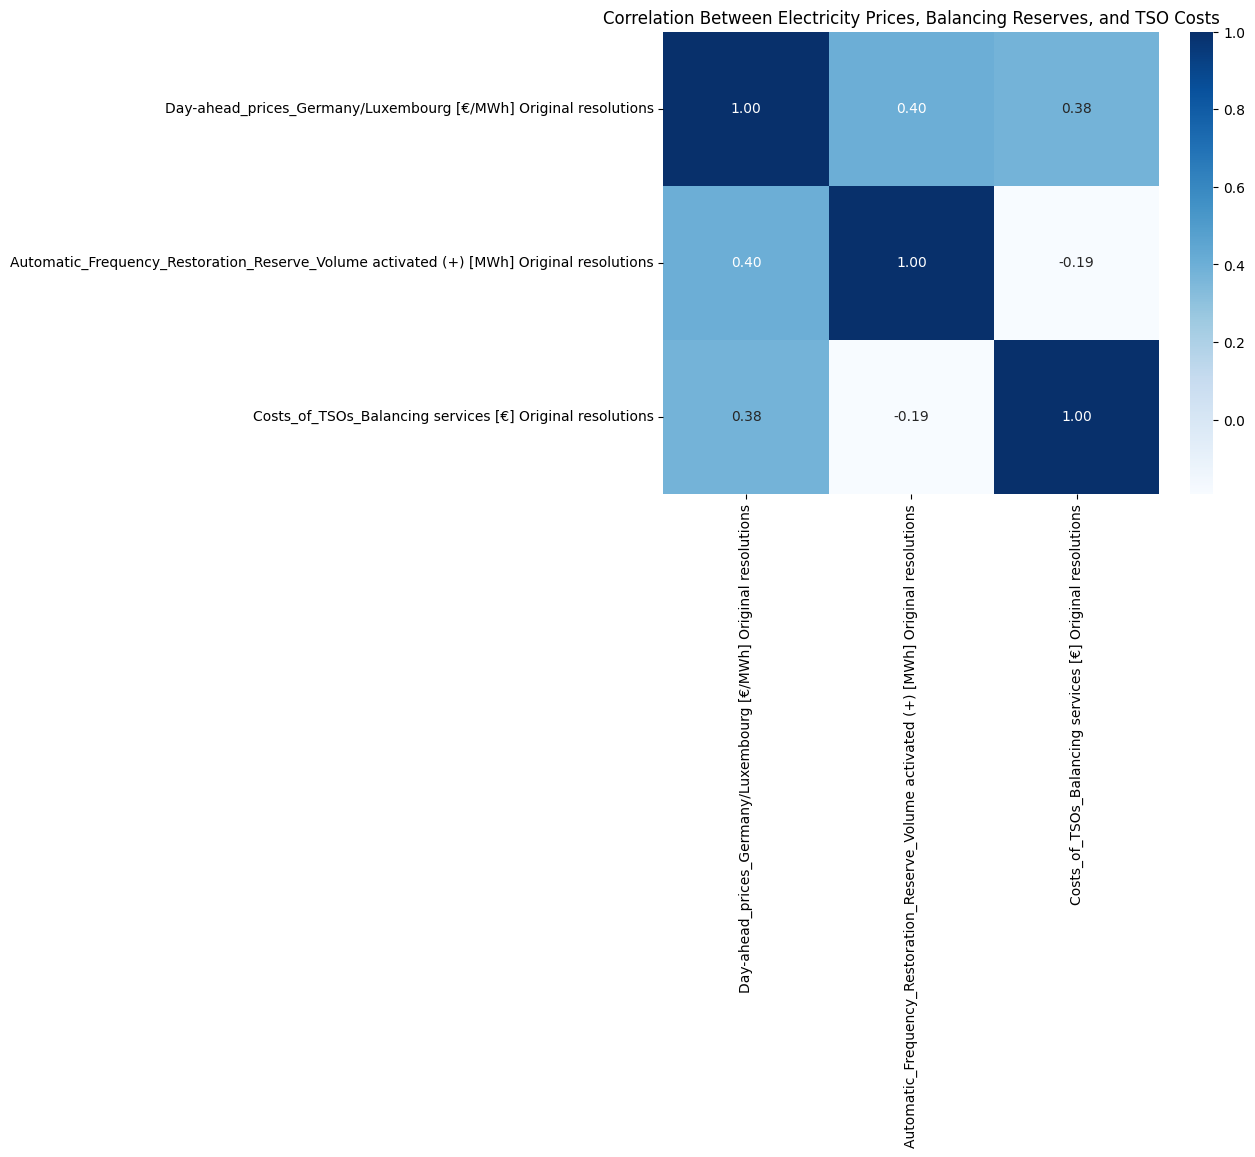

In [43]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f', cbar=True)
plt.title('Correlation Between Electricity Prices, Balancing Reserves, and TSO Costs')
plt.show()

### **3. Price & Consumption Impact Analysis**

- #### *How do scheduled commercial exchanges influence price fluctuations?*

In [55]:
scheduled_columns = [
    'Scheduled_commercial_exchanges_Net export [MWh]',
    'Scheduled_commercial_exchanges_Netherlands (export) [MWh]',
    'Scheduled_commercial_exchanges_Netherlands (import) [MWh]',
    'Scheduled_commercial_exchanges_Switzerland (export) [MWh]',
    'Scheduled_commercial_exchanges_Switzerland (import) [MWh]',
    'Scheduled_commercial_exchanges_Denmark (export) [MWh]',
    'Scheduled_commercial_exchanges_Denmark (import) [MWh]',
    'Scheduled_commercial_exchanges_Czech Republic (export) [MWh]',
    'Scheduled_commercial_exchanges_Czech Republic (import) [MWh]',
    'Scheduled_commercial_exchanges_Luxembourg (export) [MWh]',
    'Scheduled_commercial_exchanges_Luxembourg (import) [MWh]',
    'Scheduled_commercial_exchanges_Sweden (export) [MWh]',
    'Scheduled_commercial_exchanges_Sweden (import) [MWh]',
    'Scheduled_commercial_exchanges_Austria (export) [MWh]',
    'Scheduled_commercial_exchanges_Austria (import) [MWh]',
    'Scheduled_commercial_exchanges_France (export) [MWh]',
    'Scheduled_commercial_exchanges_France (import) [MWh]',
    'Scheduled_commercial_exchanges_Poland (export) [MWh]',
    'Scheduled_commercial_exchanges_Poland (import) [MWh]',
    'Scheduled_commercial_exchanges_Norway (export) [MWh]',
    'Scheduled_commercial_exchanges_Norway (import) [MWh]',
    'Scheduled_commercial_exchanges_Belgium (export) [MWh]',
    'Scheduled_commercial_exchanges_Belgium (import) [MWh]'
]

df['Price_fluctuation'] = df['Day-ahead_prices_Germany/Luxembourg [€/MWh] Original resolutions'].pct_change() * 100

correlation_matrix = df[['Price_fluctuation'] + scheduled_columns].corr()

In [56]:
correlation_matrix

,Price_fluctuation,Scheduled_commercial_exchanges_Net export [MWh],Scheduled_commercial_exchanges_Netherlands (export) [MWh],Scheduled_commercial_exchanges_Netherlands (import) [MWh],Scheduled_commercial_exchanges_Switzerland (export) [MWh],Scheduled_commercial_exchanges_Switzerland (import) [MWh],Scheduled_commercial_exchanges_Denmark (export) [MWh],Scheduled_commercial_exchanges_Denmark (import) [MWh],Scheduled_commercial_exchanges_Czech Republic (export) [MWh],Scheduled_commercial_exchanges_Czech Republic (import) [MWh],...,Scheduled_commercial_exchanges_Austria (export) [MWh],Scheduled_commercial_exchanges_Austria (import) [MWh],Scheduled_commercial_exchanges_France (export) [MWh],Scheduled_commercial_exchanges_France (import) [MWh],Scheduled_commercial_exchanges_Poland (export) [MWh],Scheduled_commercial_exchanges_Poland (import) [MWh],Scheduled_commercial_exchanges_Norway (export) [MWh],Scheduled_commercial_exchanges_Norway (import) [MWh],Scheduled_commercial_exchanges_Belgium (export) [MWh],Scheduled_commercial_exchanges_Belgium (import) [MWh]
Price_fluctuation,1.000000,0.003038,-0.000074,0.001440,0.003436,0.003560,0.000069,0.000078,-0.000559,0.001046,...,0.000894,-0.000587,0.005214,0.003910,-0.003440,-0.001054,0.000544,-0.000608,0.000730,0.002168
Scheduled_commercial_exchanges_Net export [MWh],0.003038,1.000000,-0.193875,-0.075096,0.442028,0.656937,0.654263,0.643412,0.670377,0.243263,...,0.740061,0.453966,0.340610,-0.102246,0.510749,0.354401,0.702301,0.751437,0.474817,0.537493
Scheduled_commercial_exchanges_Netherlands (export) [MWh],-0.000074,-0.193875,1.000000,0.515001,0.219962,0.055458,-0.518790,-0.489035,-0.485902,0.274679,...,-0.212059,0.082844,-0.048194,-0.057028,-0.053580,-0.049834,-0.526953,-0.301688,-0.283909,-0.148829
Scheduled_commercial_exchanges_Netherlands (import) [MWh],0.001440,-0.075096,0.515001,1.000000,0.096609,-0.075640,-0.401295,-0.457493,-0.397905,0.056787,...,-0.292624,-0.116299,0.229795,0.276810,-0.304635,-0.167104,-0.437848,-0.302737,0.038307,0.001387
Scheduled_commercial_exchanges_Switzerland (export) [MWh],0.003436,0.442028,0.219962,0.096609,1.000000,0.654013,-0.048973,-0.031119,0.121082,0.287565,...,0.371487,0.359016,0.217339,-0.034758,0.192172,0.117355,0.030204,0.132330,0.175425,0.270441
Scheduled_commercial_exchanges_Switzerland (import) [MWh],0.003560,0.656937,0.055458,-0.075640,0.654013,1.000000,0.229804,0.293463,0.360109,0.302354,...,0.567675,0.480484,0.082319,-0.249702,0.393968,0.222087,0.342488,0.466968,0.171231,0.315140
Scheduled_commercial_exchanges_Denmark (export) [MWh],0.000069,0.654263,-0.518790,-0.401295,-0.048973,0.229804,1.000000,0.817866,0.622019,-0.125209,...,0.477868,0.107164,-0.022970,-0.268325,0.417197,0.178163,0.874528,0.738384,0.247962,0.277266
Scheduled_commercial_exchanges_Denmark (import) [MWh],0.000078,0.643412,-0.489035,-0.457493,-0.031119,0.293463,0.817866,1.000000,0.579438,-0.176133,...,0.506986,0.101573,-0.080741,-0.380974,0.439498,0.153616,0.881100,0.822302,0.181356,0.324480
Scheduled_commercial_exchanges_Czech Republic (export) [MWh],-0.000559,0.670377,-0.485902,-0.397905,0.121082,0.360109,0.622019,0.579438,1.000000,0.163884,...,0.811821,0.345022,-0.065954,-0.344619,0.711225,0.377664,0.712310,0.625695,0.268422,0.289447
Scheduled_commercial_exchanges_Czech Republic (import) [MWh],0.001046,0.243263,0.274679,0.056787,0.287565,0.302354,-0.125209,-0.176133,0.163884,1.000000,...,0.370926,0.724143,-0.067501,-0.209457,0.383403,0.685801,-0.087674,0.031492,-0.118659,-0.063323


- #### *What is the impact of cross-border physical flows on electricity prices?*

In [54]:
cross_border_columns = [
    'Cross-border_physical_flows_Net export [MWh] Original resolutions',
    'Cross-border_physical_flows_Netherlands (export) [MWh] Original resolutions',
    'Cross-border_physical_flows_Netherlands (import) [MWh] Original resolutions',
    'Cross-border_physical_flows_Switzerland (export) [MWh] Original resolutions',
    'Cross-border_physical_flows_Switzerland (import) [MWh] Original resolutions',
    'Cross-border_physical_flows_Denmark (export) [MWh] Original resolutions',
    'Cross-border_physical_flows_Denmark (import) [MWh] Original resolutions',
    'Cross-border_physical_flows_Czech Republic (export) [MWh] Original resolutions',
    'Cross-border_physical_flows_Czech Republic (import) [MWh] Original resolutions',
    'Cross-border_physical_flows_Luxembourg (export) [MWh] Original resolutions',
    'Cross-border_physical_flows_Luxembourg (import) [MWh] Original resolutions',
    'Cross-border_physical_flows_Sweden (export) [MWh] Original resolutions',
    'Cross-border_physical_flows_Sweden (import) [MWh] Original resolutions',
    'Cross-border_physical_flows_Austria (export) [MWh] Original resolutions',
    'Cross-border_physical_flows_Austria (import) [MWh] Original resolutions',
    'Cross-border_physical_flows_France (export) [MWh] Original resolutions',
    'Cross-border_physical_flows_France (import) [MWh] Original resolutions',
    'Cross-border_physical_flows_Poland (export) [MWh] Original resolutions',
    'Cross-border_physical_flows_Poland (import) [MWh] Original resolutions',
    'Cross-border_physical_flows_Norway (export) [MWh] Original resolutions',
    'Cross-border_physical_flows_Norway (import) [MWh] Original resolutions',
    'Cross-border_physical_flows_Belgium (export) [MWh] Original resolutions',
    'Cross-border_physical_flows_Belgium (import) [MWh] Original resolutions',
    'Day-ahead_prices_Germany/Luxembourg [€/MWh] Original resolutions'
]

correlation_matrix = df[cross_border_columns].corr()
correlation_matrix

,Cross-border_physical_flows_Net export [MWh] Original resolutions,Cross-border_physical_flows_Netherlands (export) [MWh] Original resolutions,Cross-border_physical_flows_Netherlands (import) [MWh] Original resolutions,Cross-border_physical_flows_Switzerland (export) [MWh] Original resolutions,Cross-border_physical_flows_Switzerland (import) [MWh] Original resolutions,Cross-border_physical_flows_Denmark (export) [MWh] Original resolutions,Cross-border_physical_flows_Denmark (import) [MWh] Original resolutions,Cross-border_physical_flows_Czech Republic (export) [MWh] Original resolutions,Cross-border_physical_flows_Czech Republic (import) [MWh] Original resolutions,Cross-border_physical_flows_Luxembourg (export) [MWh] Original resolutions,...,Cross-border_physical_flows_Austria (import) [MWh] Original resolutions,Cross-border_physical_flows_France (export) [MWh] Original resolutions,Cross-border_physical_flows_France (import) [MWh] Original resolutions,Cross-border_physical_flows_Poland (export) [MWh] Original resolutions,Cross-border_physical_flows_Poland (import) [MWh] Original resolutions,Cross-border_physical_flows_Norway (export) [MWh] Original resolutions,Cross-border_physical_flows_Norway (import) [MWh] Original resolutions,Cross-border_physical_flows_Belgium (export) [MWh] Original resolutions,Cross-border_physical_flows_Belgium (import) [MWh] Original resolutions,Day-ahead_prices_Germany/Luxembourg [€/MWh] Original resolutions
Cross-border_physical_flows_Net export [MWh] Original resolutions,1.000000,-0.034614,-0.254773,0.615867,0.601674,0.688525,0.660951,0.535709,0.362701,-0.275121,...,0.291117,0.265222,0.242811,0.467256,0.199202,0.663841,0.753151,0.386194,0.627409,-0.636888
Cross-border_physical_flows_Netherlands (export) [MWh] Original resolutions,-0.034614,1.000000,0.685626,-0.187643,0.110788,-0.381310,-0.529795,0.222448,-0.013465,-0.257861,...,0.374980,-0.089948,-0.390154,0.037201,0.098511,-0.353608,-0.154095,-0.157073,0.079033,0.158001
Cross-border_physical_flows_Netherlands (import) [MWh] Original resolutions,-0.254773,0.685626,1.000000,-0.153862,-0.057549,-0.626947,-0.623294,-0.066223,-0.364903,0.208504,...,0.238090,0.087740,-0.001089,-0.365583,-0.077658,-0.661696,-0.473515,0.078404,-0.172358,0.529062
Cross-border_physical_flows_Switzerland (export) [MWh] Original resolutions,0.615867,-0.187643,-0.153862,1.000000,0.540780,0.215610,0.293073,0.212620,-0.114449,0.052789,...,0.251149,0.473657,0.514670,0.029538,-0.003875,0.200646,0.231928,0.543632,0.299105,-0.157910
Cross-border_physical_flows_Switzerland (import) [MWh] Original resolutions,0.601674,0.110788,-0.057549,0.540780,1.000000,0.182439,0.187553,0.303641,-0.047165,-0.152401,...,0.459512,0.176303,0.265800,0.082558,0.004081,0.171577,0.301585,0.319181,0.445389,-0.267937
Cross-border_physical_flows_Denmark (export) [MWh] Original resolutions,0.688525,-0.381310,-0.626947,0.215610,0.182439,1.000000,0.810122,0.225240,0.432900,-0.379414,...,-0.178951,-0.036736,-0.039256,0.477039,0.097684,0.920156,0.813201,0.014222,0.388960,-0.782607
Cross-border_physical_flows_Denmark (import) [MWh] Original resolutions,0.660951,-0.529795,-0.623294,0.293073,0.187553,0.810122,1.000000,0.134063,0.288807,-0.169236,...,-0.258867,0.043591,0.174575,0.308996,0.011397,0.778328,0.764131,0.183283,0.339909,-0.669721
Cross-border_physical_flows_Czech Republic (export) [MWh] Original resolutions,0.535709,0.222448,-0.066223,0.212620,0.303641,0.225240,0.134063,1.000000,0.583294,-0.292901,...,0.547600,-0.109759,-0.225424,0.589851,0.378477,0.265297,0.327739,0.044442,0.268891,-0.325688
Cross-border_physical_flows_Czech Republic (import) [MWh] Original resolutions,0.362701,-0.013465,-0.364903,-0.114449,-0.047165,0.432900,0.288807,0.583294,1.000000,-0.486926,...,0.277078,-0.335644,-0.455335,0.715663,0.462615,0.484624,0.451030,-0.281795,0.163678,-0.564333
Cross-border_physical_flows_Luxembourg (export) [MWh] Original resolutions,-0.275121,-0.257861,0.208504,0.052789,-0.152401,-0.379414,-0.169236,-0.2929